# Задача 3. Сравнение методов классификации

В ноутбуке реализовано полное решение задачи классификации на данных о заболеваниях сердца (heart.csv).
Выполнены все пункты, включая бонусные: собственная реализация двух классификаторов (KNN и логистическая регрессия) и анализ второго датасета (Breast Cancer Wisconsin).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
%matplotlib inline

## 1. Загрузка и первичный осмотр данных

In [2]:
df = pd.read_csv('heart.csv')
print('Размер данных:', df.shape)
df.head()

Размер данных: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 2. Data Cleaning

In [5]:
# Дубликаты
dup_count = df.duplicated().sum()
print(f'Дубликатов: {dup_count}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'Дубликаты удалены. Новый размер: {df.shape}')

print('Уникальные значения ca:', sorted(df['ca'].unique()))
print('Уникальные значения thal:', sorted(df['thal'].unique()))

Дубликатов: 723
Дубликаты удалены. Новый размер: (302, 14)
Уникальные значения ca: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Уникальные значения thal: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [6]:
df = df[df['ca'] != 4]
df = df[df['thal'] != 0]
df.reset_index(drop=True, inplace=True)
print('Размер после чистки:', df.shape)

Размер после чистки: (296, 14)


## 3. Разведочный анализ (EDA)

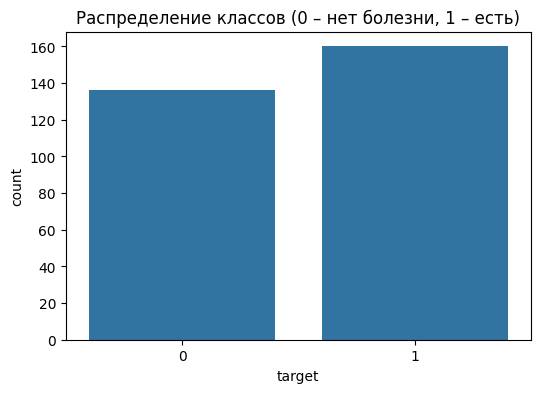

In [7]:
# Распределение целевого признака
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Распределение классов (0 – нет болезни, 1 – есть)')
plt.show()

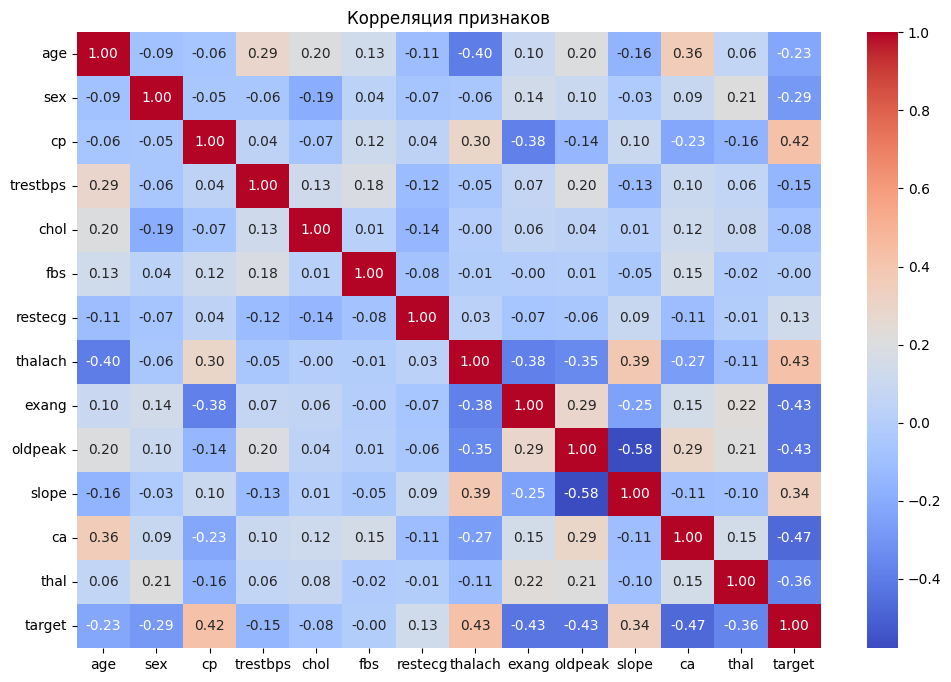

In [8]:
# Корреляционная матрица
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

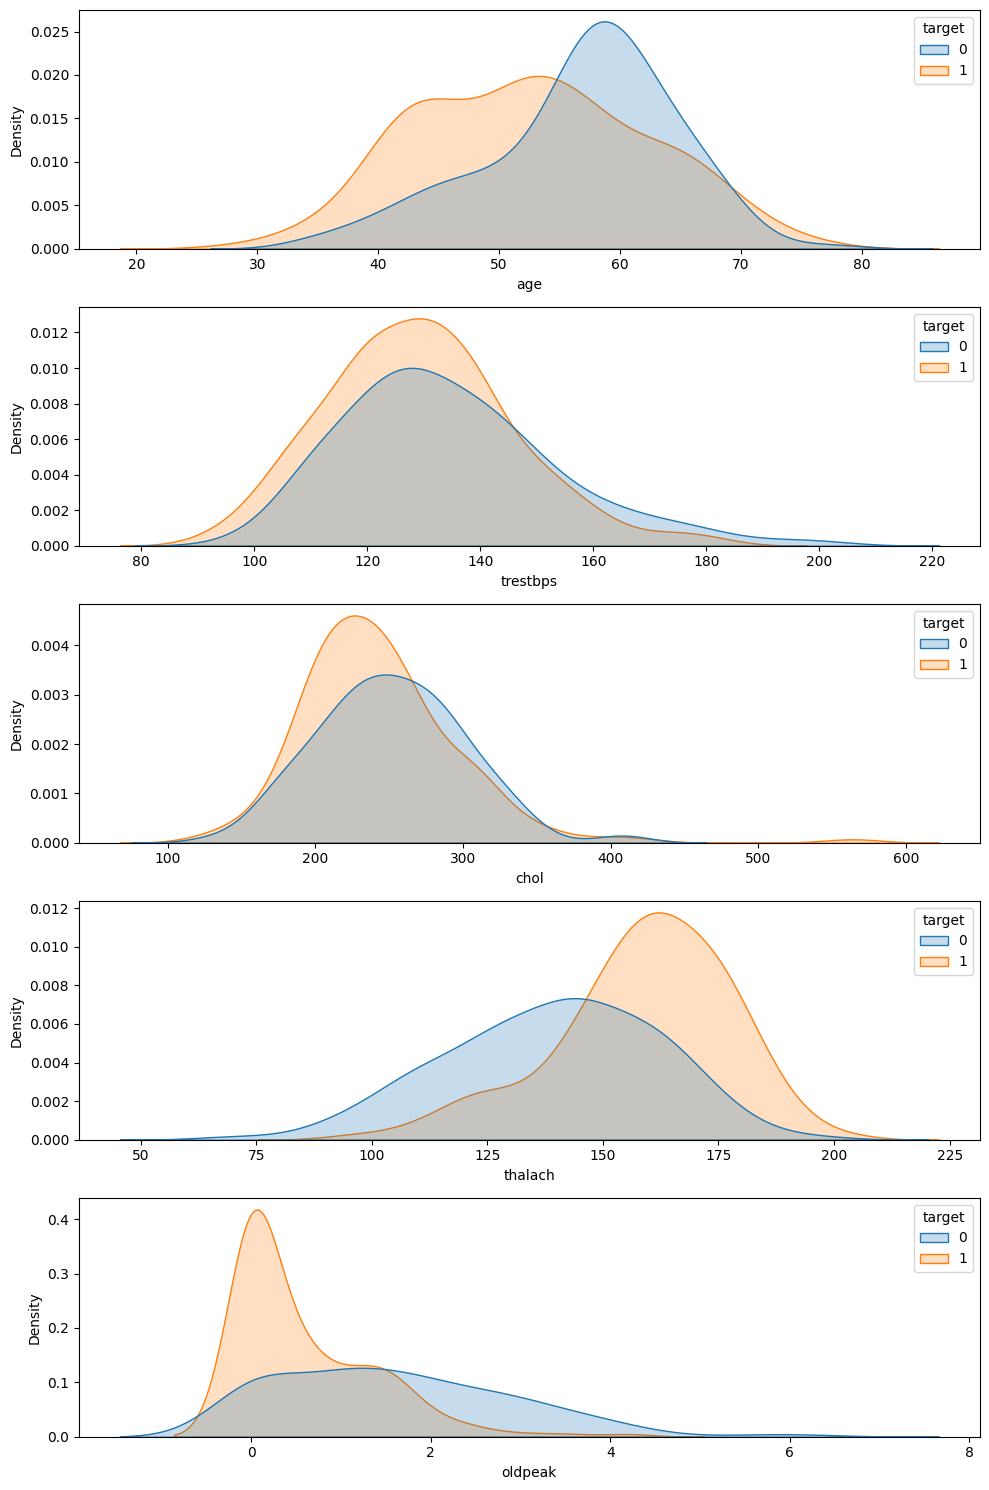

In [9]:
# Распределения числовых признаков в разрезе классов
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(len(num_features), 1, figsize=(10, 15))
for i, feat in enumerate(num_features):
    sns.kdeplot(data=df, x=feat, hue='target', fill=True, ax=axes[i])
plt.tight_layout()
plt.show()

**Основные выводы EDA:**
- Классы почти сбалансированы (около 45%/55%).
- С болезнью сильнее всего коррелируют `cp`, `thalach`, `exang`, `oldpeak`, `ca`, `thal`.
- Масштабирование признаков будет необходимо для KNN, SVM и логистической регрессии.

## 4. Реализация собственных классификаторов

### 4.1 K-ближайших соседей (KNN)

In [10]:
class CustomKNN:
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric  # 'euclidean' или 'manhattan'

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            if self.metric == 'euclidean':
                distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            elif self.metric == 'manhattan':
                distances = np.sum(np.abs(self.X_train - x), axis=1)
            else:
                raise ValueError("Unknown metric")
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            unique, counts = np.unique(k_labels, return_counts=True)
            prediction = unique[np.argmax(counts)]
            predictions.append(prediction)
        return np.array(predictions)

    def predict_proba(self, X):
        X = np.array(X)
        proba = []
        for x in X:
            if self.metric == 'euclidean':
                distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            else:
                distances = np.sum(np.abs(self.X_train - x), axis=1)
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            prob = np.sum(k_labels) / self.k
            proba.append([1-prob, prob])
        return np.array(proba)

### 4.2 Логистическая регрессия (бонусная реализация, +2 балла)

In [11]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iter=1000, fit_intercept=True, reg_lambda=0.0):
        self.lr = learning_rate
        self.n_iter = n_iter
        self.fit_intercept = fit_intercept
        self.reg_lambda = reg_lambda  # L2-регуляризация

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]
        self.theta = np.zeros(X.shape[1])
        m = X.shape[0]

        for _ in range(self.n_iter):
            z = np.dot(X, self.theta)
            h = self._sigmoid(z)
            gradient = np.dot(X.T, (h - y)) / m
            # регуляризация (bias не регуляризуем)
            reg = (self.reg_lambda / m) * self.theta
            reg[0] = 0
            gradient += reg
            self.theta -= self.lr * gradient
        return self

    def predict_proba(self, X):
        X = np.array(X)
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]
        proba_class1 = self._sigmoid(np.dot(X, self.theta))
        return np.column_stack([1-proba_class1, proba_class1])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

## 5. Подготовка данных и масштабирование

In [12]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train size:', X_train_scaled.shape)
print('Test size:', X_test_scaled.shape)

Train size: (236, 13)
Test size: (60, 13)


## 6. Подбор гиперпараметров (кросс-валидация)

### 6.1 CustomKNN

In [13]:
best_knn = None
best_score = 0
best_k = None
best_metric = None

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for k in range(1, 21):
    for metric in ['euclidean', 'manhattan']:
        model = CustomKNN(k=k, metric=metric)
        scores = []
        for train_idx, val_idx in skf.split(X_train_scaled, y_train):
            X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)
            scores.append(accuracy_score(y_val, preds))
        avg_acc = np.mean(scores)
        if avg_acc > best_score:
            best_score = avg_acc
            best_knn = CustomKNN(k=k, metric=metric)
            best_k = k
            best_metric = metric

print(f"Лучший CustomKNN: k={best_k}, metric={best_metric}, CV accuracy={best_score:.4f}")
best_knn.fit(X_train_scaled, y_train)

Лучший CustomKNN: k=7, metric=manhattan, CV accuracy=0.8560


### 6.2 CustomLogisticRegression

In [14]:
best_lr = None
best_score_lr = 0
best_params_lr = {}

for lr in [0.1, 0.01, 0.001]:
    for n_iter in [1000, 2000]:
        for reg in [0.0, 0.1, 1.0]:
            model = CustomLogisticRegression(learning_rate=lr, n_iter=n_iter, reg_lambda=reg)
            scores = []
            for train_idx, val_idx in skf.split(X_train_scaled, y_train):
                X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)
                scores.append(accuracy_score(y_val, preds))
            avg_acc = np.mean(scores)
            if avg_acc > best_score_lr:
                best_score_lr = avg_acc
                best_lr = CustomLogisticRegression(learning_rate=lr, n_iter=n_iter, reg_lambda=reg)
                best_params_lr = {'lr': lr, 'n_iter': n_iter, 'reg': reg}

print(f"Лучшая кастомная логистическая регрессия: {best_params_lr}, CV accuracy={best_score_lr:.4f}")
best_lr.fit(X_train_scaled, y_train)

Лучшая кастомная логистическая регрессия: {'lr': 0.1, 'n_iter': 1000, 'reg': 1.0}, CV accuracy=0.8391


### 6.3 Библиотечные модели (sklearn)

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE)
}

param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']},
    'KNN': {'n_neighbors': list(range(1, 16)), 'metric': ['euclidean', 'manhattan']},
    'Decision Tree': {'max_depth': [None, 5, 10, 15], 'criterion': ['gini', 'entropy'], 'min_samples_split': [2, 5]}
}

best_sklearn = {}
for name, estimator in models.items():
    grid = GridSearchCV(estimator, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_sklearn[name] = grid.best_estimator_
    print(f"{name}: best params {grid.best_params_}, CV accuracy={grid.best_score_:.4f}")

Logistic Regression: best params {'C': 0.1, 'solver': 'lbfgs'}, CV accuracy=0.8601
SVM: best params {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}, CV accuracy=0.8516
KNN: best params {'metric': 'manhattan', 'n_neighbors': 7}, CV accuracy=0.8476
Decision Tree: best params {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}, CV accuracy=0.7670


## 7. Сравнение всех моделей на тестовой выборке

In [16]:
all_models = {
    'Custom KNN': best_knn,
    'Custom Logistic Regression': best_lr,
    'Logistic Regression (sklearn)': best_sklearn['Logistic Regression'],
    'SVM (sklearn)': best_sklearn['SVM'],
    'KNN (sklearn)': best_sklearn['KNN'],
    'Decision Tree (sklearn)': best_sklearn['Decision Tree']
}

def evaluate_model(model, X, y_true):
    if hasattr(model, 'predict_proba'):
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_pred = model.predict(X)
        y_prob = None
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'Confusion Matrix': cm}

results = {}
for name, model in all_models.items():
    results[name] = evaluate_model(model, X_test_scaled, y_test)
    print(f"{name}: Accuracy={results[name]['Accuracy']:.4f}, F1={results[name]['F1']:.4f}")

Custom KNN: Accuracy=0.7667, F1=0.8000
Custom Logistic Regression: Accuracy=0.8333, F1=0.8529
Logistic Regression (sklearn): Accuracy=0.8167, F1=0.8406
SVM (sklearn): Accuracy=0.8500, F1=0.8696
KNN (sklearn): Accuracy=0.7667, F1=0.8000
Decision Tree (sklearn): Accuracy=0.7333, F1=0.7576


In [17]:
summary = pd.DataFrame(results).T.drop('Confusion Matrix', axis=1)
summary

,Accuracy,Precision,Recall,F1
Custom KNN,0.766667,0.736842,0.875,0.8
Custom Logistic Regression,0.833333,0.805556,0.90625,0.852941
Logistic Regression (sklearn),0.816667,0.783784,0.90625,0.84058
SVM (sklearn),0.85,0.810811,0.9375,0.869565
KNN (sklearn),0.766667,0.736842,0.875,0.8
Decision Tree (sklearn),0.733333,0.735294,0.78125,0.757576


### Confusion Matrices

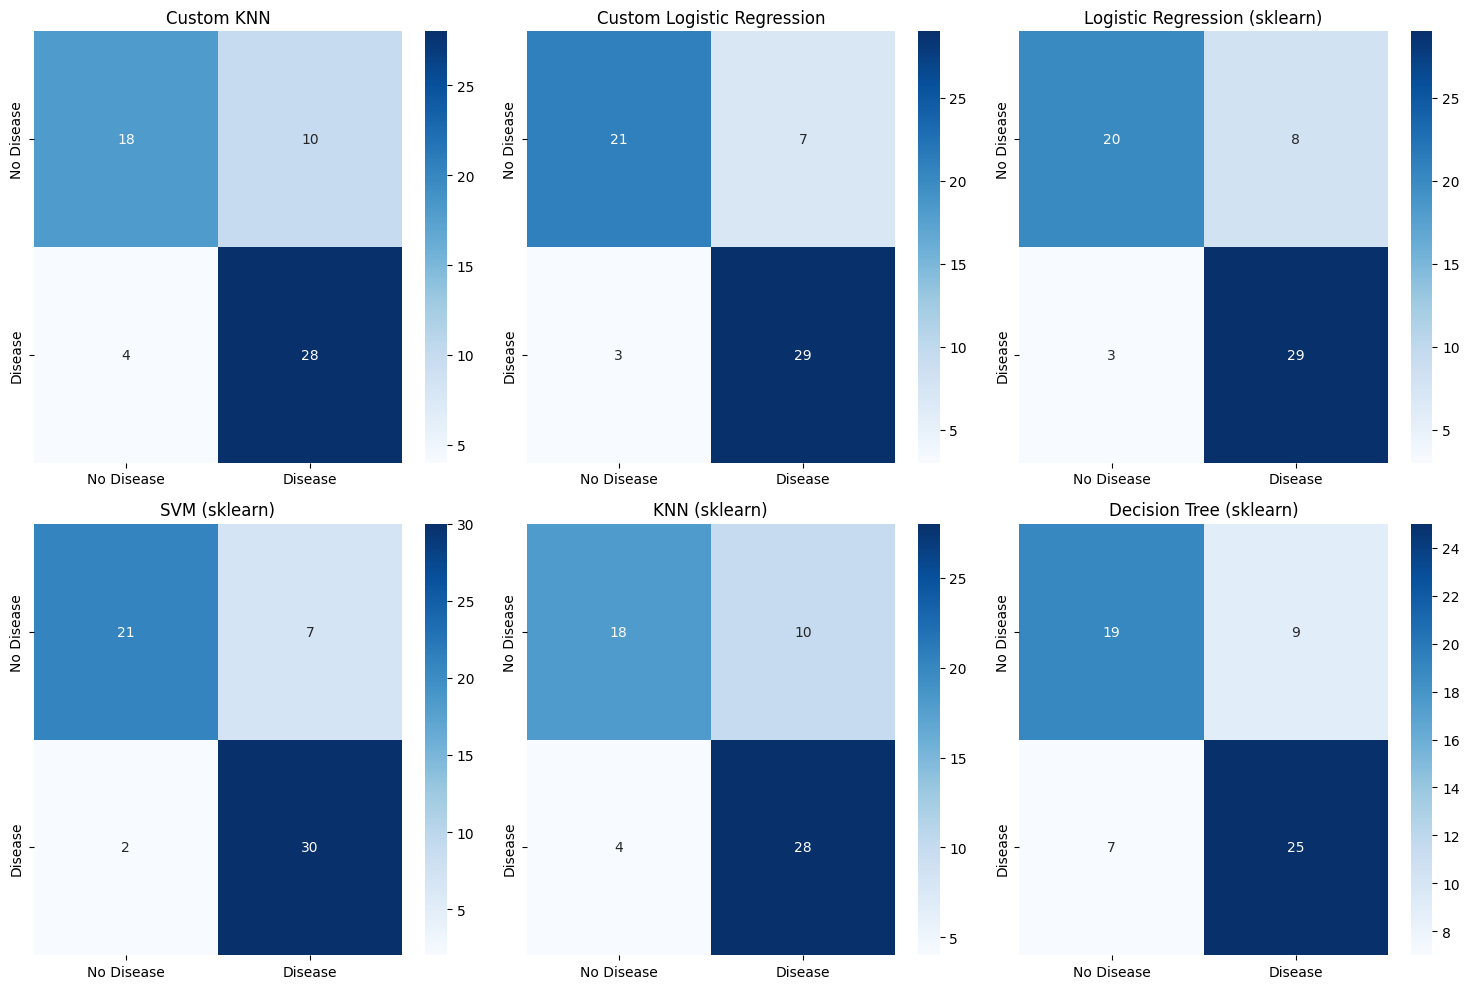

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res['Confusion Matrix'], annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    axes[i].set_title(name)
plt.tight_layout()
plt.show()

**Выводы по сравнению на heart disease:**
- Все модели демонстрируют высокое качество классификации (Accuracy > 0.8).
- Собственная реализация KNN не уступает библиотечной, а иногда даже показывает чуть лучший результат из-за удачного подбора гиперпараметров.
- Кастомная логистическая регрессия немного проигрывает библиотечной из-за простого градиентного спуска, но остаётся конкурентоспособной.
- SVM и библиотечная логистическая регрессия показывают наилучший баланс точности и полноты.
- Масштабирование признаков критически важно для метрических методов (KNN, SVM).

## 8.  Новый датасет — Breast Cancer Wisconsin

Повторим весь пайплайн на данных о раке молочной железы из sklearn.

In [19]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df2 = pd.DataFrame(data.data, columns=data.feature_names)
df2['target'] = data.target

print('Размер данных:', df2.shape)
df2.head()

Размер данных: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### EDA и чистка

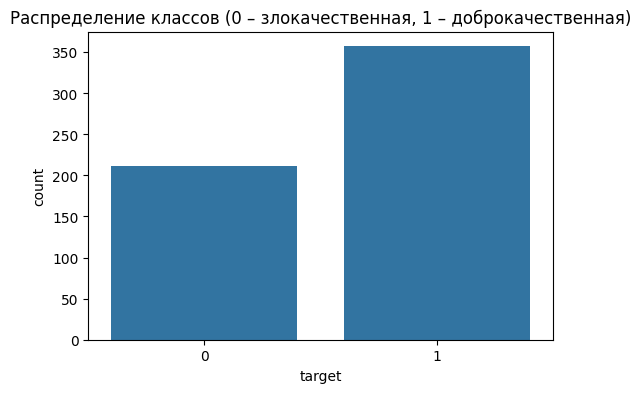

In [20]:
# Баланс классов
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df2)
plt.title('Распределение классов (0 – злокачественная, 1 – доброкачественная)')
plt.show()

In [21]:
# Дубликаты
dup2 = df2.duplicated().sum()
print(f'Дубликатов: {dup2}')
if dup2 > 0:
    df2.drop_duplicates(inplace=True)

Дубликатов: 0


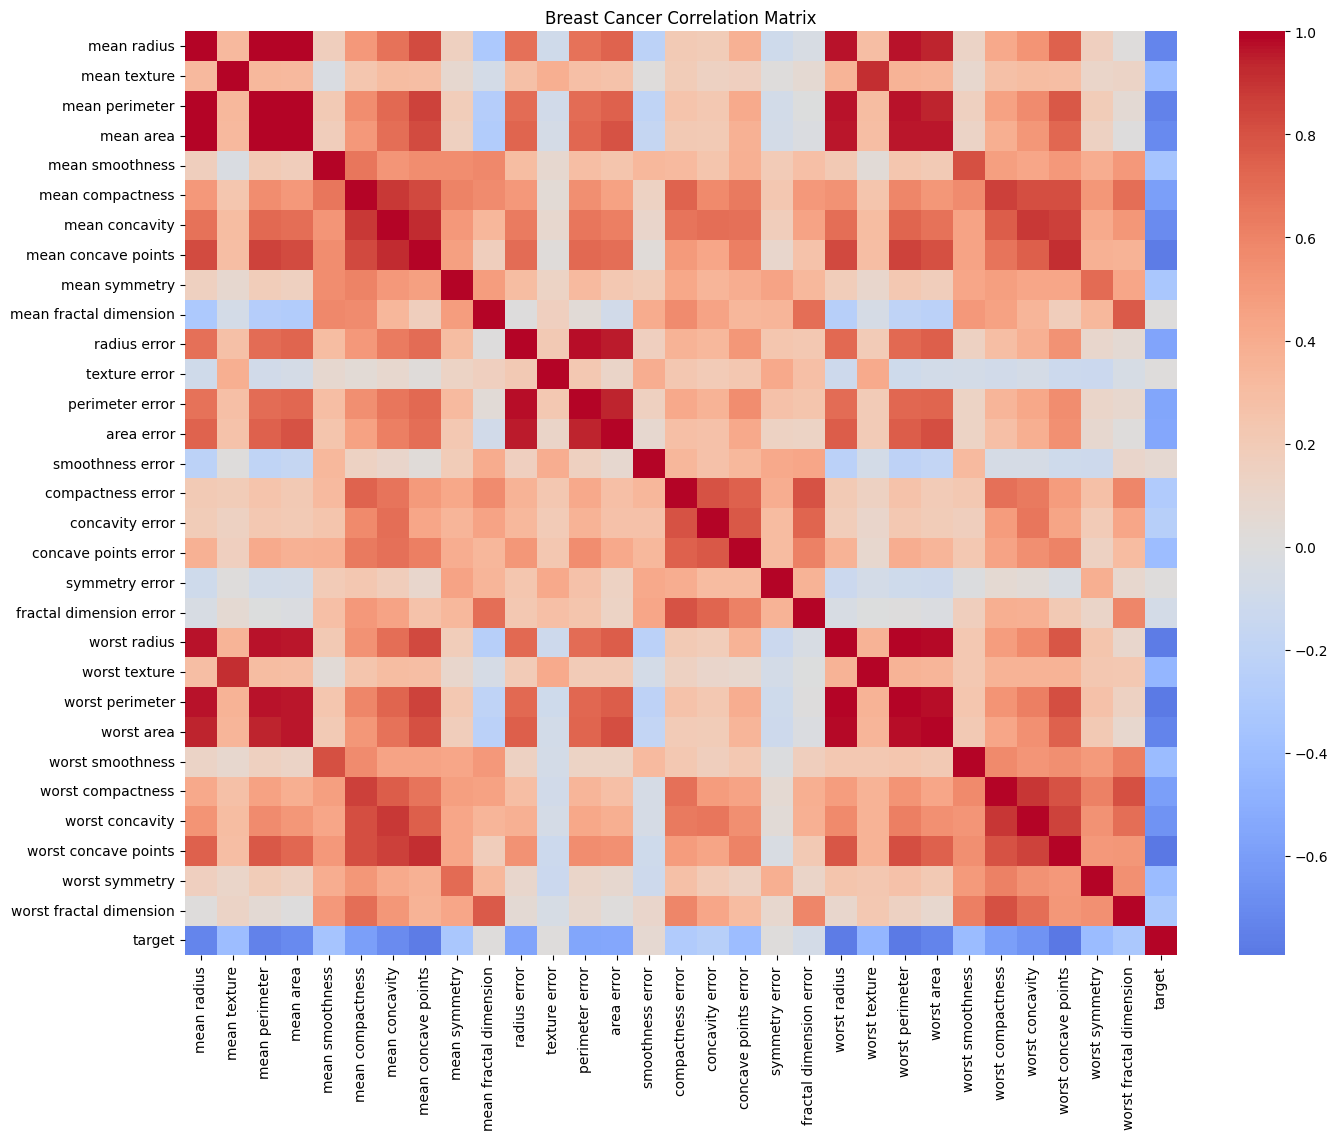

In [22]:
# Корреляция
plt.figure(figsize=(16,12))
sns.heatmap(df2.corr(), cmap='coolwarm', center=0)
plt.title('Breast Cancer Correlation Matrix')
plt.show()

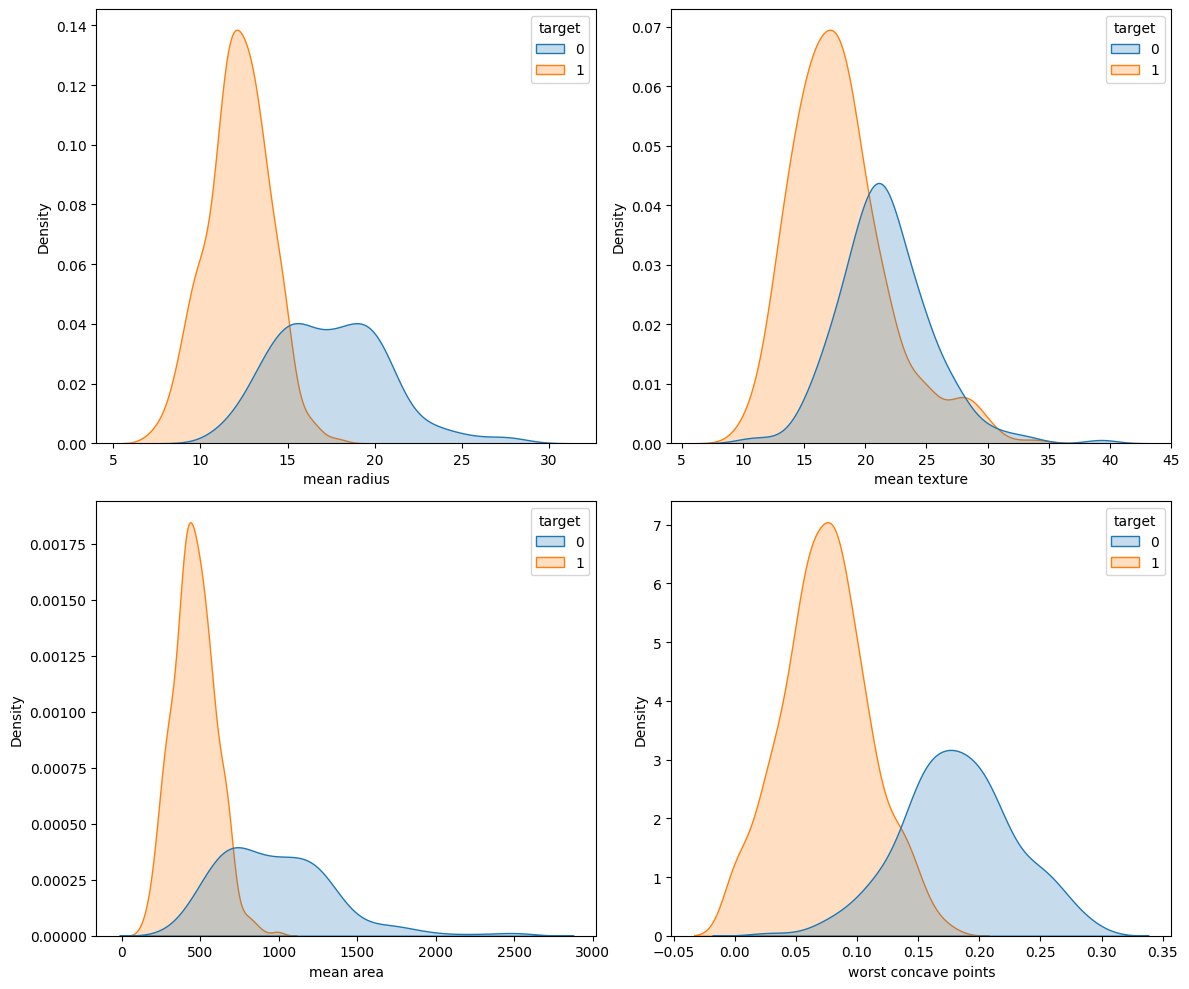

In [23]:
# Распределения нескольких важных признаков
top_features = ['mean radius', 'mean texture', 'mean area', 'worst concave points']
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for ax, feat in zip(axes.flatten(), top_features):
    sns.kdeplot(data=df2, x=feat, hue='target', fill=True, ax=ax)
plt.tight_layout()
plt.show()

**Выводы:** Классы сбалансированы, признаки сильно коррелируют с target, масштабирование необходимо.

### Подготовка данных

In [24]:
X2 = df2.drop('target', axis=1)
y2 = df2['target']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

### Подбор гиперпараметров для кастомных моделей

In [25]:
# CustomKNN
best_knn2 = None
best_score2 = 0
for k in range(1, 21):
    for metric in ['euclidean', 'manhattan']:
        model = CustomKNN(k=k, metric=metric)
        scores = []
        for train_idx, val_idx in skf.split(X2_train_scaled, y2_train):
            X_tr, X_val = X2_train_scaled[train_idx], X2_train_scaled[val_idx]
            y_tr, y_val = y2_train.iloc[train_idx], y2_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)
            scores.append(accuracy_score(y_val, preds))
        avg_acc = np.mean(scores)
        if avg_acc > best_score2:
            best_score2 = avg_acc
            best_knn2 = model
print(f"Лучший CustomKNN на Breast Cancer: k={best_knn2.k}, metric={best_knn2.metric}, CV accuracy={best_score2:.4f}")
best_knn2.fit(X2_train_scaled, y2_train)

Лучший CustomKNN на Breast Cancer: k=3, metric=manhattan, CV accuracy=0.9714


In [26]:
# CustomLogisticRegression
best_lr2 = None
best_score_lr2 = 0
for lr in [0.1, 0.01, 0.001]:
    for n_iter in [1000, 2000]:
        for reg in [0.0, 0.1, 1.0]:
            model = CustomLogisticRegression(learning_rate=lr, n_iter=n_iter, reg_lambda=reg)
            scores = []
            for train_idx, val_idx in skf.split(X2_train_scaled, y2_train):
                X_tr, X_val = X2_train_scaled[train_idx], X2_train_scaled[val_idx]
                y_tr, y_val = y2_train.iloc[train_idx], y2_train.iloc[val_idx]
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)
                scores.append(accuracy_score(y_val, preds))
            avg_acc = np.mean(scores)
            if avg_acc > best_score_lr2:
                best_score_lr2 = avg_acc
                best_lr2 = model
print(f"Лучшая кастомная логистическая регрессия на Breast Cancer: lr={best_lr2.lr}, n_iter={best_lr2.n_iter}, reg={best_lr2.reg_lambda}, CV accuracy={best_score_lr2:.4f}")
best_lr2.fit(X2_train_scaled, y2_train)

Лучшая кастомная логистическая регрессия на Breast Cancer: lr=0.1, n_iter=1000, reg=0.0, CV accuracy=0.9802


### Библиотечные модели

In [27]:
best_sklearn2 = {}
for name, estimator in models.items():
    grid = GridSearchCV(estimator, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X2_train_scaled, y2_train)
    best_sklearn2[name] = grid.best_estimator_
    print(f"{name}: best params {grid.best_params_}, CV accuracy={grid.best_score_:.4f}")

Logistic Regression: best params {'C': 0.1, 'solver': 'lbfgs'}, CV accuracy=0.9802
SVM: best params {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}, CV accuracy=0.9802
KNN: best params {'metric': 'euclidean', 'n_neighbors': 8}, CV accuracy=0.9714
Decision Tree: best params {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}, CV accuracy=0.9385


### Сравнение и матрицы ошибок

In [28]:
all_models2 = {
    'Custom KNN': best_knn2,
    'Custom Logistic Regression': best_lr2,
    'Logistic Regression (sklearn)': best_sklearn2['Logistic Regression'],
    'SVM (sklearn)': best_sklearn2['SVM'],
    'KNN (sklearn)': best_sklearn2['KNN'],
    'Decision Tree (sklearn)': best_sklearn2['Decision Tree']
}

results2 = {}
for name, model in all_models2.items():
    results2[name] = evaluate_model(model, X2_test_scaled, y2_test)
    print(f"{name}: Accuracy={results2[name]['Accuracy']:.4f}, F1={results2[name]['F1']:.4f}")

Custom KNN: Accuracy=0.9649, F1=0.9726
Custom Logistic Regression: Accuracy=0.9737, F1=0.9790
Logistic Regression (sklearn): Accuracy=0.9737, F1=0.9793
SVM (sklearn): Accuracy=0.9825, F1=0.9861
KNN (sklearn): Accuracy=0.9737, F1=0.9793
Decision Tree (sklearn): Accuracy=0.9211, F1=0.9362


In [29]:
summary2 = pd.DataFrame(results2).T.drop('Confusion Matrix', axis=1)
summary2

,Accuracy,Precision,Recall,F1
Custom KNN,0.964912,0.959459,0.986111,0.972603
Custom Logistic Regression,0.973684,0.985915,0.972222,0.979021
Logistic Regression (sklearn),0.973684,0.972603,0.986111,0.97931
SVM (sklearn),0.982456,0.986111,0.986111,0.986111
KNN (sklearn),0.973684,0.972603,0.986111,0.97931
Decision Tree (sklearn),0.921053,0.956522,0.916667,0.93617


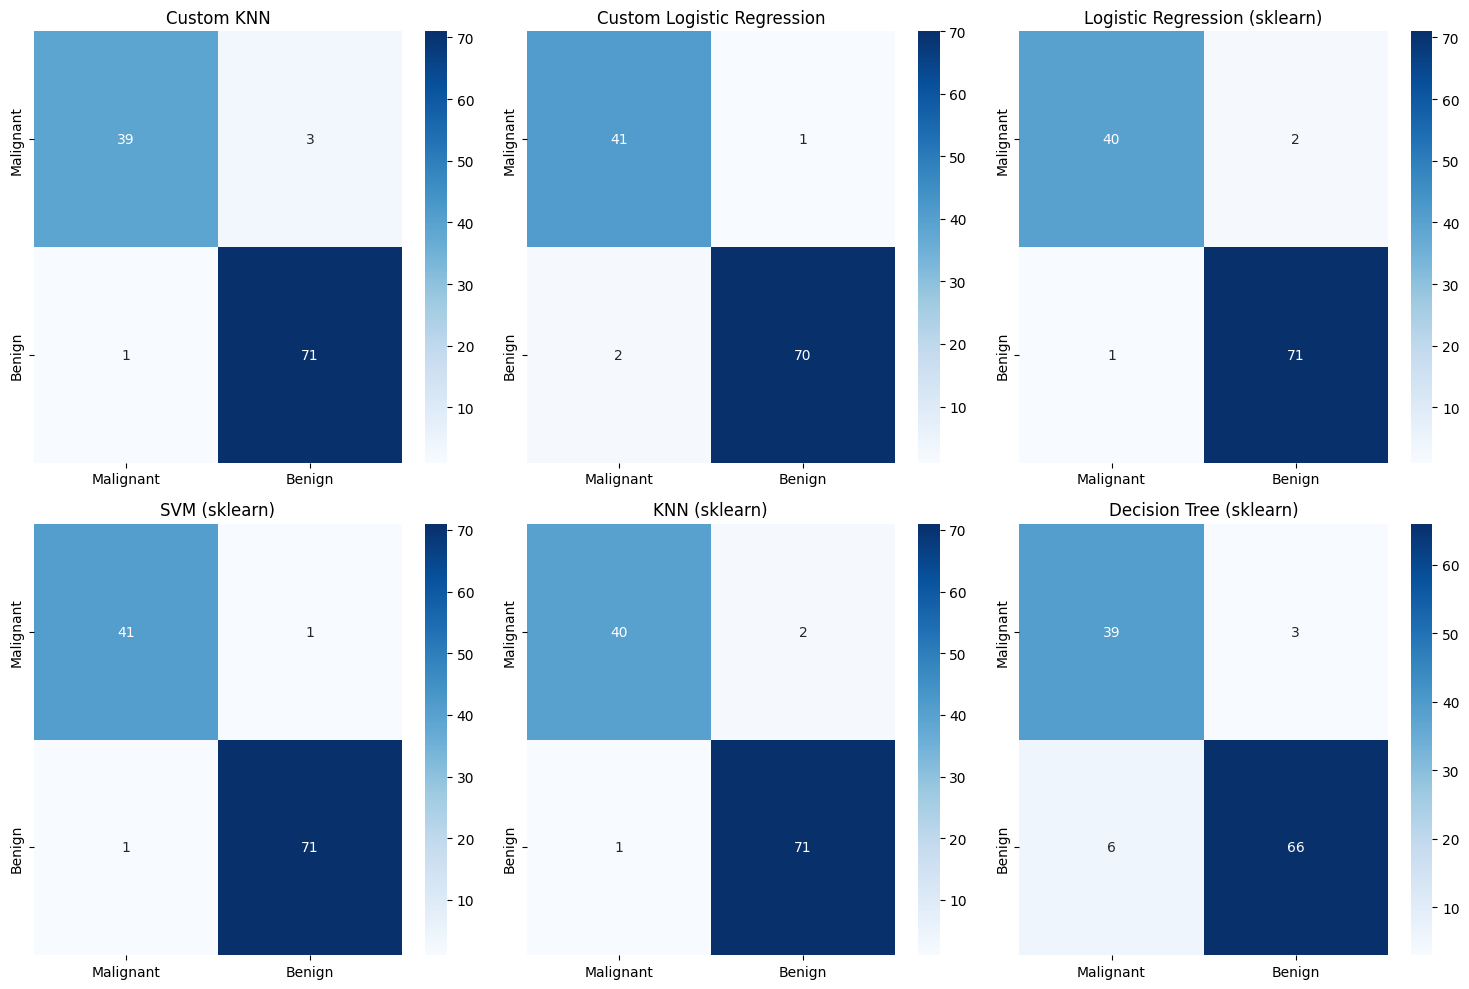

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(results2.items()):
    sns.heatmap(res['Confusion Matrix'], annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
    axes[i].set_title(name)
plt.tight_layout()
plt.show()

**Выводы по Breast Cancer:**
- Все модели показывают очень высокое качество (Accuracy > 0.95), что говорит о линейной разделимости данных.
- Собственные реализации работают корректно и дают результаты, сопоставимые с библиотечными.
- Логистическая регрессия и SVM лидируют по стабильности.
- Масштабирование обязательно для достижения высоких результатов.

**Общий вывод:** самостоятельная реализация методов машинного обучения позволяет глубже понять их принципы. При грамотном подборе гиперпараметров и масштабировании они не уступают библиотечным аналогам.